# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [55]:
# importar librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [56]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [57]:
# mostrar las primeras 5 filas de plans
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [58]:
# mostrar las primeras 5 filas de users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [59]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [60]:
# revisar el número de filas y columnas de cada dataset

print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [61]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [62]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [63]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [66]:
# cantidad de nulos para users
print("Cantidad de valores nulos:")
print(users.isna().sum())

print("\nProporción de valores nulos:")
print((users.isna().mean() * 100).round(2))

Cantidad de valores nulos:
user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64

Proporción de valores nulos:
user_id        0.00
first_name     0.00
last_name      0.00
age            0.00
city          11.72
reg_date       0.00
plan           0.00
churn_date    88.35
dtype: float64


In [67]:
# cantidad de nulos para usage
print("Cantidad de valores nulos:")
print(usage.isna().sum())

print("\nProporción de valores nulos:")
print((usage.isna().mean() * 100).round(2))

Cantidad de valores nulos:
id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64

Proporción de valores nulos:
id           0.00
user_id      0.00
type         0.00
date         0.12
duration    55.19
length      44.74
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

- En `users`, la columna `city` presenta 469 valores nulos (**11.72 %**). Estos valores requieren revisión antes de decidir si deben imputarse o mantenerse como desconocidos.

- `churn_date` presenta 3534 valores nulos (**88.35 %**). No se eliminará la columna de forma automática, ya que la ausencia de una fecha de baja puede representar clientes que no han abandonado el servicio.

- En `usage`, `date` presenta 50 valores nulos (**0.12 %**). Al ser una proporción muy pequeña y tratarse de una variable necesaria para el análisis temporal, estos registros pueden considerarse para eliminación.

- `duration` presenta 22 076 valores nulos (**55.19 %**) y `length` 17 896 (**44.74 %**). Antes de imputarlos o eliminarlos, se verificará si estos valores están relacionados con `type`, ya que `duration` corresponde a llamadas y `length` a mensajes.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [68]:
# explorar columnas numéricas de users
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id`presenta valores entre 10000 y 13999, correspondientes a los identificadores de los 4000 usuarios. No se observan valores numéricos fuera del rango esperado.
- La columna `age`contiene un valor mínimo de -999, que no representa una edad válida y corresponde a un valor sentinel. Este valor deberá reemplazarse posteriormente durante la limpieza.

In [69]:
# explorar columnas numéricas de usage
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id`. `id` presenta valores entre 1 y 40000, correspondientes a los registros de uso. `user_id` se encuentra entre 10000 y 13999, dentro del rango de usuarios observado en `users`. No se detectan valores inválidos evidentes en estas columnas.
- Las columnas `duration` presenta valores entre 0 y 120 minutos, mientras que `length` presenta valores entre 0 y 1490. Estos valores máximos podrían representar consumos elevados, por lo que posteriormente se revisarán mediante el análisis de outliers.

In [70]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']

for col in columnas_user:
    print(f"\nValores de {col}:")
    print(users[col].value_counts(dropna=False))



Valores de city:
Bogotá      808
CDMX        730
Medellín    616
NaN         469
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64

Valores de plan:
Basico     2595
Premium    1405
Name: plan, dtype: int64


- La columna `city` contiene 469 valores nulos y 96 registros con el valor `?`. El valor `?` funciona como sentinel para ciudades desconocidas y deberá convertirse a `NaN` durante la limpieza.
- La columna `plan` contiene únicamente las categorías `Basico` y `Premium`, que coinciden con los planes disponibles en el dataset `plans`. No se observan categorías inválidas.

In [71]:
# explorar columna categórica de usage
usage['type'].value_counts(dropna=False)

text    22092
call    17908
Name: type, dtype: int64

- La columna `type` contiene únicamente `text` (22092 registros) y `call` (17908 registros). No se observan categorías inválidas.

---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?

Se identificó el valor sentinel `-999` en la columna `age`, ya que no representa una edad válida. Se reemplazará por la mediana de las edades válidas.

En `city` se encontraron 96 registros con `?`, que representan ciudades desconocidas. Estos valores se convertirán a `NaN`.

No se identificaron categorías inválidas en `plan` ni en `type`. Los valores extremos de `duration` y `length` se analizarán posteriormente mediante métodos de detección de outliers antes de decidir si requieren tratamiento.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [72]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

In [73]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [74]:
# Revisar los años presentes en `reg_date` de users
print(users['reg_date'].dt.year.value_counts().sort_index())

2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64


En `reg_date` se observan registros de 2022, 2023 y 2024, pero también aparecen 40 registros correspondientes al año 2026. Debido a que los datos del proyecto están registrados hasta 2024, estas 40 fechas se consideran fuera del rango válido.

In [75]:
# Revisar los años presentes en `date` de usage
print(usage['date'].dt.year.value_counts().sort_index())

2024.0    39950
Name: date, dtype: int64


En `date` se observan 39,950 registros correspondientes a 2024. No se detectan años fuera del rango esperado. Los 50 registros restantes corresponden a fechas nulas identificadas previamente.
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?

En `users['reg_date']` se identificaron 40 registros correspondientes al año 2026. Estos valores son inconsistentes, ya que el periodo de análisis comprende datos registrados hasta 2024. Por lo tanto, estas fechas deberán marcarse como valores nulos (`NaT`) durante la limpieza.

En `usage['date']` no se encontraron años fuera del rango esperado; los registros con fecha válida corresponden a 2024. Los 50 valores nulos detectados previamente se mantendrán identificados para su tratamiento durante la limpieza.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [76]:
# Calcular la mediana excluyendo el valor sentinel -999
age_mediana = users.loc[users['age'] != -999, 'age'].median()

# Reemplazar -999 por la mediana de age
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [77]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
print(users['city'].value_counts(dropna=False))

Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64


In [78]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Verificar cambios
print(users['reg_date'].dt.year.value_counts(dropna=False).sort_index())

2022.0    1314
2023.0    1316
2024.0    1330
NaN         40
Name: reg_date, dtype: int64


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [79]:
# Verificación MAR en usage (Missing At Random) para duration
# Verificación de nulos en duration según type
print(pd.crosstab(
    usage['type'],
    usage['duration'].isna(),
    margins=True
))

duration  False   True    All
type                         
call      17908      0  17908
text         16  22076  22092
All       17924  22076  40000


In [80]:
# Verificación MAR en usage (Missing At Random) para length
# Verificación de nulos en length según type
print(pd.crosstab(
    usage['type'],
    usage['length'].isna(),
    margins=True
))

length  False   True    All
type                       
call       12  17896  17908
text    22092      0  22092
All     22104  17896  40000


Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`

Los valores nulos dependen principalmente del tipo de actividad (`type`). En los registros de tipo `call`, `duration` está presente en las 17,908 llamadas, mientras que `length` es nulo en 17,896 casos. En los registros de tipo `text`, `length` está presente en los 22,092 mensajes, mientras que `duration` es nulo en 22,076 casos.

Por lo tanto, estos valores nulos son esperados debido a la estructura del dataset y no deben imputarse ni eliminarse de forma general. Sin embargo, se identificaron 16 registros `text` con un valor en `duration` y 12 registros `call` con un valor en `length`, que representan inconsistencias menores y podrían revisarse por separado.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [81]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas

# Agrupar información por usuario
usage_agg = usage.groupby("user_id").agg({
    "is_text": "sum",
    "is_call": "sum",
    "duration": "sum"
}).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [82]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    'is_text': 'cant_mensajes',
    'is_call': 'cant_llamadas',
    'duration': 'total_minutos_llamada'
})

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,total_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [83]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(
    usage_agg,
    on='user_id',
    how='left'
)

# observar resultado
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,total_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [84]:
# Resumen estadístico de las columnas numéricas
user_profile[
    ['age', 'cant_mensajes', 'cant_llamadas', 'total_minutos_llamada']
].describe()

,age,cant_mensajes,cant_llamadas,total_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.136000,5.524381,4.478120,23.317054
std,17.689919,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [85]:
# Distribución porcentual del tipo de plan
(user_profile['plan'].value_counts(normalize=True) * 100).round(2)

Basico     64.88
Premium    35.12
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

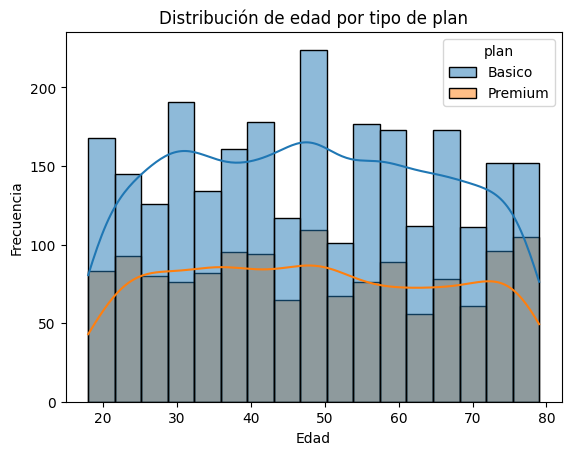

In [86]:
# Histograma para visualizar la edad (age)
sns.histplot(
    data=user_profile,
    x='age',
    hue='plan',
    kde=True
)

plt.title('Distribución de edad por tipo de plan')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- Distribución: Las edades de los clientes se distribuyen a lo largo de todo el rango analizado (18–79 años), sin observarse una concentración extrema en un único grupo de edad. Ambos planes presentan clientes de distintas edades. El plan Básico muestra frecuencias mayores, lo cual es consistente con su mayor proporción de usuarios en la muestra (64.88 %).

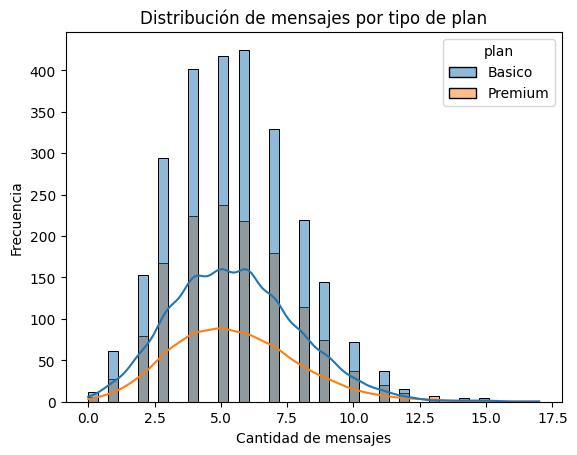

In [87]:
# Histograma para visualizar la cant_mensajes
sns.histplot(
    data=user_profile,
    x='cant_mensajes',
    hue='plan',
    kde=True
)

plt.title('Distribución de mensajes por tipo de plan')
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- Distribución: La cantidad de mensajes se concentra principalmente alrededor de 3 a 8 mensajes por usuario, con mayor frecuencia cerca de 5–6. La distribución presenta un ligero sesgo hacia la derecha, debido a un pequeño número de usuarios con cantidades de mensajes considerablemente mayores. Los planes Básico y Premium muestran patrones de distribución similares, aunque el Básico presenta frecuencias absolutas mayores debido a que cuenta con más usuarios.

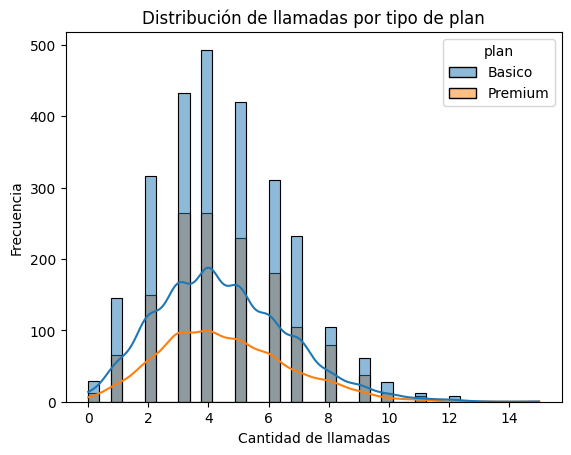

In [88]:
# Histograma para visualizar la cant_llamadas
sns.histplot(
    data=user_profile,
    x='cant_llamadas',
    hue='plan',
    kde=True
)

plt.title('Distribución de llamadas por tipo de plan')
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- Distribución: La cantidad de llamadas se concentra principalmente entre 2 y 7 llamadas por usuario, con mayor frecuencia alrededor de 4 llamadas. La distribución presenta un ligero sesgo hacia la derecha, debido a la presencia de algunos usuarios con un número de llamadas considerablemente mayor. Los planes Básico y Premium muestran patrones similares, aunque el plan Básico presenta frecuencias absolutas mayores debido a su mayor cantidad de usuarios.

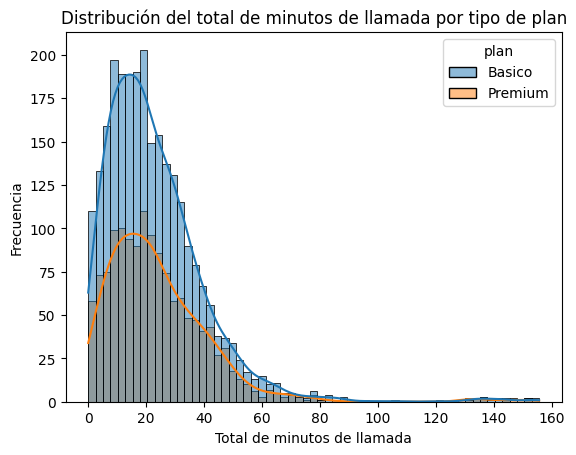

In [89]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(
    data=user_profile,
    x='total_minutos_llamada',
    hue='plan',
    kde=True
)

plt.title('Distribución del total de minutos de llamada por tipo de plan')
plt.xlabel('Total de minutos de llamada')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 
- Distribución: El total de minutos de llamada presenta una distribución sesgada hacia la derecha. La mayoría de los usuarios concentra un consumo relativamente bajo o moderado, principalmente por debajo de 40 minutos, mientras que un pequeño grupo presenta valores considerablemente mayores. Se observan algunos casos extremos cercanos a 140–155 minutos, que deberán analizarse como posibles outliers. Los planes Básico y Premium muestran una forma de distribución similar.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

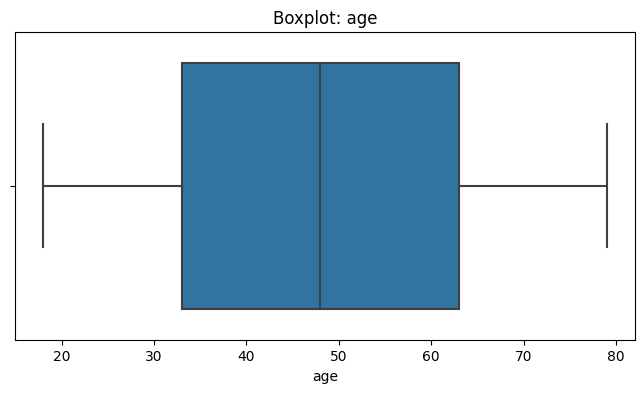

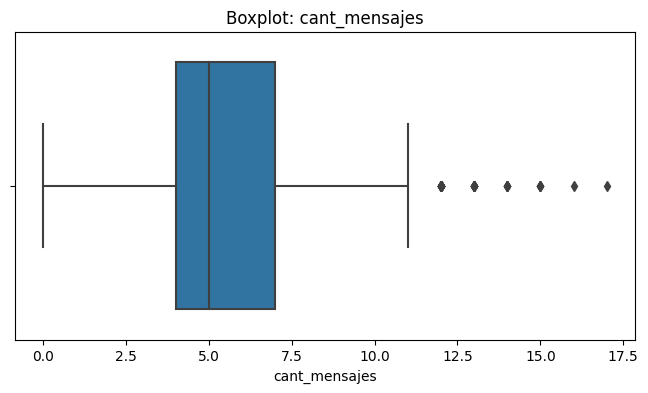

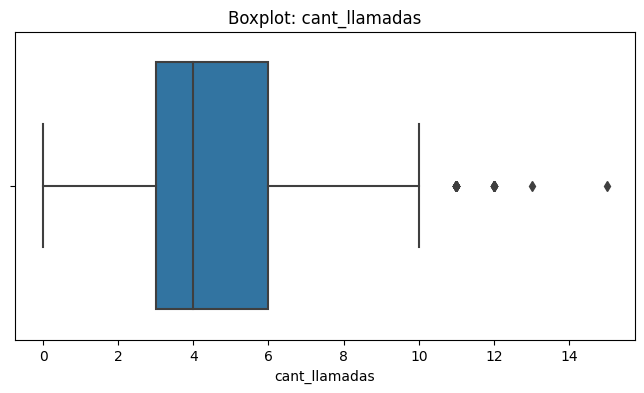

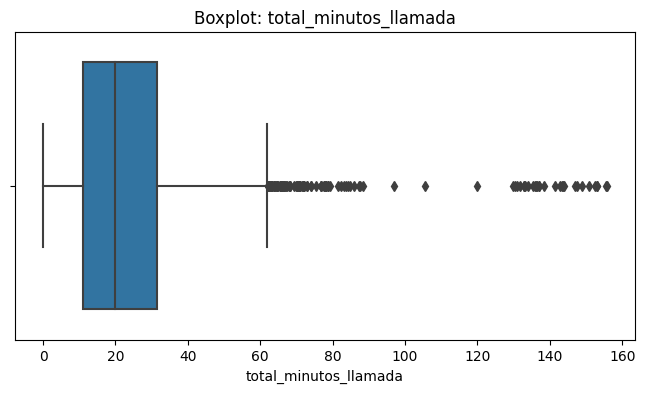

In [90]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'total_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=user_profile[col])
    plt.title(f'Boxplot: {col}')
    plt.xlabel(col)
    plt.show()

💡Insights: 
- Age: No presenta outliers visibles; las edades se encuentran dentro de los límites del boxplot.
- cant_mensajes: Presenta algunos outliers superiores correspondientes a usuarios con una cantidad de mensajes mayor que la mayoría.
- cant_llamadas: Presenta algunos outliers superiores correspondientes a usuarios con un número de llamadas inusualmente alto.
- cant_minutos_llamada: Presenta numerosos outliers superiores y algunos valores extremadamente altos, lo que indica usuarios con tiempos acumulados de llamada considerablemente mayores que el comportamiento típico.

In [91]:
# Calcular límites con el método IQR
columnas_limites = [
    'cant_mensajes',
    'cant_llamadas',
    'total_minutos_llamada'
]

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    
    print(f'{col}:')
    print(f'Q1 = {Q1:.2f}')
    print(f'Q3 = {Q3:.2f}')
    print(f'IQR = {IQR:.2f}')
    print(f'Límite inferior = {limite_inferior:.2f}')
    print(f'Límite superior = {limite_superior:.2f}')
    print()

cant_mensajes:
Q1 = 4.00
Q3 = 7.00
IQR = 3.00
Límite inferior = -0.50
Límite superior = 11.50

cant_llamadas:
Q1 = 3.00
Q3 = 6.00
IQR = 3.00
Límite inferior = -1.50
Límite superior = 10.50

total_minutos_llamada:
Q1 = 11.12
Q3 = 31.41
IQR = 20.30
Límite inferior = -19.32
Límite superior = 61.86



In [92]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,total_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 

- **cant_mensajes**: Se mantienen los outliers. El límite superior según el método IQR es 11.5 mensajes y el máximo observado es 17. Aunque existen valores atípicos, son plausibles y pueden representar usuarios con un nivel de uso elevado.

- **cant_llamadas**: Se mantienen los outliers. El límite superior según el método IQR es 10.5 llamadas y el máximo es 15. Estos valores pueden corresponder a usuarios de alto consumo y no existe evidencia de que sean errores.

- **total_minutos_llamada**: Se mantienen los outliers. El límite superior según el método IQR es 61.86 minutos y el máximo alcanza 155.69 minutos. Aunque existen valores considerablemente altos, pueden representar comportamientos reales de usuarios intensivos y son relevantes para identificar patrones de consumo atípicos.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [93]:
# Crear columna grupo_uso
user_profile['grupo_uso'] = np.where(
    (user_profile['cant_llamadas'] < 5) &
    (user_profile['cant_mensajes'] < 5),
    'Bajo uso',
    np.where(
        (user_profile['cant_llamadas'] < 10) &
        (user_profile['cant_mensajes'] < 10),
        'Uso medio',
        'Alto uso'
    )
)

In [94]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,total_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [95]:
# Crear columna grupo_edad
user_profile['grupo_edad'] = np.where(
    user_profile['age'] < 30,
    'Joven',
    np.where(
        user_profile['age'] < 60,
        'Adulto',
        'Adulto Mayor'
    )
)

In [96]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,total_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

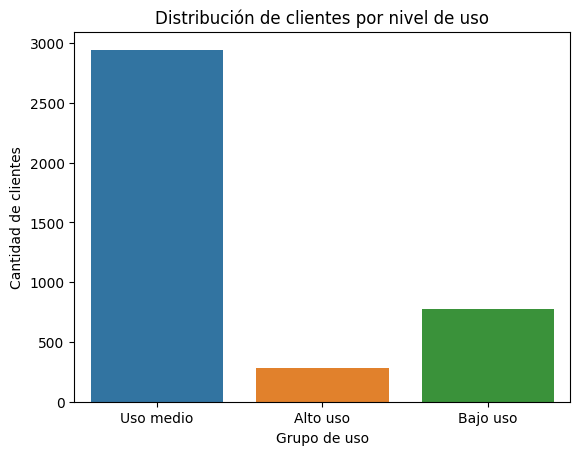

In [97]:
# Visualización de los segmentos por uso
sns.countplot(
    data=user_profile,
    x='grupo_uso'
)

plt.title('Distribución de clientes por nivel de uso')
plt.xlabel('Grupo de uso')
plt.ylabel('Cantidad de clientes')
plt.show()

In [98]:
# Visualización de los segmentos por edad


In [99]:
# Cantidad y porcentaje de clientes por grupo de uso
print("Segmentación por nivel de uso:")
print(user_profile['grupo_uso'].value_counts())

print("\nPorcentaje por nivel de uso:")
print((user_profile['grupo_uso'].value_counts(normalize=True) * 100).round(2))

print("\nSegmentación por grupo de edad:")
print(user_profile['grupo_edad'].value_counts())

print("\nPorcentaje por grupo de edad:")
print((user_profile['grupo_edad'].value_counts(normalize=True) * 100).round(2))

Segmentación por nivel de uso:
Uso medio    2943
Bajo uso      778
Alto uso      279
Name: grupo_uso, dtype: int64

Porcentaje por nivel de uso:
Uso medio    73.58
Bajo uso     19.45
Alto uso      6.98
Name: grupo_uso, dtype: float64

Segmentación por grupo de edad:
Adulto          2018
Adulto Mayor    1222
Joven            760
Name: grupo_edad, dtype: int64

Porcentaje por grupo de edad:
Adulto          50.45
Adulto Mayor    30.55
Joven           19.00
Name: grupo_edad, dtype: float64


In [100]:
# Analizar segmentos por edad, uso y plan
segmentos = pd.crosstab(
    [user_profile['grupo_edad'], user_profile['grupo_uso']],
    user_profile['plan'],
    margins=True
)

segmentos

plan                    Basico  Premium   All
grupo_edad   grupo_uso                       
Adulto       Alto uso      108       46   154
             Bajo uso      240      124   364
             Uso medio     977      523  1500
Adulto Mayor Alto uso       43       31    74
             Bajo uso      173       84   257
             Uso medio     568      323   891
Joven        Alto uso       35       16    51
             Bajo uso       99       58   157
             Uso medio     352      200   552
All                       2595     1405  4000

In [101]:
# Distribución porcentual de los planes dentro de cada grupo de uso
pd.crosstab(
    user_profile['grupo_uso'],
    user_profile['plan'],
    normalize='index'
).mul(100).round(2)

plan,Basico,Premium
grupo_uso,,
Alto uso,66.67,33.33
Bajo uso,65.81,34.19
Uso medio,64.46,35.54



---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**



- En users, la columna city presenta 469 valores nulos (11.72 %). Estos valores requieren revisión antes de decidir si deben imputarse o mantenerse como desconocidos.
- churn_date presenta 3534 valores nulos (88.35 %). No se elimina la columna de forma automática, ya que la ausencia de una fecha de baja puede representar clientes que no han abandonado el servicio. 
- En usage, date presenta 50 valores nulos (0.12 %). Al ser una proporción muy pequeña y tratarse de una variable necesaria para el análisis temporal, estos registros pueden considerarse para eliminación.
- duration presenta 22 076 valores nulos (55.19 %) y length 17 896 (44.74 %). Antes de decidir su tratamiento, se verifica si estos valores están relacionados con type, ya que duration corresponde a llamadas y length a mensajes.

🔍 **Segmentos por Edad**

- Los Adultos (30–59 años) representan el segmento más numeroso, con 2,018 clientes (50.45 %).
- Los Adultos Mayores (60 años o más) representan 1,222 clientes (30.55 %).
- Los Jóvenes (menores de 30 años) representan 760 clientes (19.00 %).
- Por lo tanto, la base de clientes de ConnectaTel está compuesta principalmente por adultos y adultos mayores.

📊 **Segmentos por Nivel de Uso**

- El segmento predominante es Uso medio, con 2,943 clientes (73.58 %).
- El segmento de Bajo uso incluye 778 clientes (19.45 %).
- El segmento de Alto uso representa solamente 279 clientes (6.98 %).
- Esto indica que la mayor parte de los clientes presenta un comportamiento de consumo intermedio, mientras que los usuarios de consumo elevado constituyen una proporción relativamente pequeña.

➡️ **Relación entre uso y plan**
- El plan Básico representa 64.88 % de los clientes y Premium 35.12 %.
- La proporción de clientes Premium es similar en los tres niveles de uso: 33.33 % en Alto uso, 34.19 % en Bajo uso y 35.54 % en Uso medio.
- Por ello, no se observa una asociación fuerte entre pertenecer al plan Premium y presentar un mayor nivel de uso. Esto representa una oportunidad para revisar si los beneficios de cada plan están suficientemente alineados con el comportamiento real de los clientes.

📈 **Valores atípicos**
- Para cant_mensajes, el método IQR estableció un límite superior de 11.50 mensajes, mientras que el máximo observado fue 17.
- Para cant_llamadas, el límite superior fue 10.50 llamadas, frente a un máximo de 15.
- Para total_minutos_llamada, el límite superior fue 61.86 minutos, mientras que el máximo alcanzó 155.69 minutos.
- Estos valores se conservaron porque pueden representar clientes con un consumo real elevado y son relevantes para analizar oportunidades comerciales. No existe evidencia suficiente en este análisis para clasificarlos directamente como fraude o errores de registro.

💡 **Recomendaciones**
- Mantener una oferta orientada al segmento de Uso medio, ya que representa casi tres cuartas partes de la base de clientes.
- Analizar a los clientes de Alto uso para determinar si los beneficios de su plan son adecuados a su nivel de consumo y evaluar oportunidades de migración hacia ofertas con mayores beneficios.
- Diseñar alternativas más ajustadas para los clientes de Bajo uso, evitando que paguen por beneficios que utilizan poco.
- Revisar la propuesta de valor del plan Premium, dado que su presencia no aumenta claramente entre los clientes de mayor uso.
- Mantener el monitoreo de los usuarios con consumos extremos para distinguir clientes de alto valor de posibles anomalías o errores de registro.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`